# 05 — LSTM Agent: Training & Backtest

Binary classification LSTM: predicts next-candle direction (up/down) on 1h BTC/USDT data.
Entry when model confidence exceeds threshold. Exit on SL/TP or confidence drop.
Results compared against buy-and-hold benchmark.

In [ ]:
# ── Configuration — edit here ────────────────────────────────────────────────
SYMBOL        = 'BTCUSDT'
INTERVAL      = '1h'
TRAIN_END     = '2024-11-10'   # ~7.2 years of training data
TEST_START    = '2024-11-10'

# Sequence
SEQ_LEN       = 168            # lookback window: 168h = 7 days

# Model
LSTM_UNITS    = 128
DROPOUT       = 0.3
EPOCHS        = 30
BATCH_SIZE    = 256
LR            = 1e-3

# Trading
CONFIDENCE_THRESHOLD = 0.65    # min buy-signal probability to enter
EXIT_THRESHOLD       = 0.45    # exit if confidence drops below this
TAKE_PROFIT          = 0.015    # +1.5%
STOP_LOSS            = 0.01    # -1%
FEE                  = 0.0005  # 0.05% per side

SEED = 42


In [2]:
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from hmats.data.binance_store import load
from hmats.data.features import FEATURE_COLS, make_features
from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

# ── Plot style ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'; RED = '#EF5350'; GREEN = '#26A69A'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
RAW_DIR     = REPO_ROOT / 'data' / 'raw'
MODELS_DIR  = REPO_ROOT / 'models'
FIGURES_DIR = REPO_ROOT / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


Device: mps


## 1. Load & prepare data

In [3]:
raw = load(SYMBOL, INTERVAL, store_dir=str(RAW_DIR))
raw.index = raw.index.tz_localize(None) if raw.index.tz else raw.index
feat_df = make_features(raw)
print(f'Feature rows: {len(feat_df):,}  {feat_df.index.min().date()} → {feat_df.index.max().date()}')
print(f'Features: {FEATURE_COLS}')


Feature rows: 76,165  2017-08-20 → 2026-05-04
Features: ['log_ret_1', 'vol_24', 'vol_72', 'sma_ratio_24_72', 'macd', 'macd_signal', 'macd_hist', 'mom_24', 'mom_72', 'rsi_14', 'volu_z_72', 'z_close_72']


## 2. Labels & train/test split

Label = 1 if next candle close > current close, else 0 (binary direction classification).

In [4]:
# Binary label: 1 = next candle up, 0 = down
feat_df['label'] = (feat_df['close'].shift(-1) > feat_df['close']).astype(int)
feat_df = feat_df.dropna()

train_df, _, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=TRAIN_END)

print(f'Train: {len(train_df):>7,} rows  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,} rows  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Train label balance: {train_df["label"].mean():.3f} (1=up)')


Train:  63,205 rows  2017-08-20 → 2024-11-10
Test:   12,960 rows  2024-11-10 → 2026-05-04
Train label balance: 0.510 (1=up)


## 3. Normalisation & sequence construction

Standardise using **train-set statistics only** — no data leakage into the test set.
Build sliding windows of length `SEQ_LEN` (7 days = 168 hourly candles).

In [5]:
X_cols = FEATURE_COLS

mu = train_df[X_cols].mean().values.astype(np.float32)
sd = (train_df[X_cols].std().values + 1e-8).astype(np.float32)

np.savez(MODELS_DIR / 'lstm_scaler.npz', mu=mu, sd=sd)

def make_sequences(df, seq_len=SEQ_LEN):
    X_raw = ((df[X_cols].values - mu) / sd).astype(np.float32)
    y_raw = df['label'].values.astype(np.float32)
    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len:i])
        ys.append(y_raw[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = make_sequences(train_df)
X_test,  y_test  = make_sequences(test_df)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')


X_train: (63037, 168, 12)  y_train: (63037,)
X_test:  (12792, 168, 12)   y_test:  (12792,)


## 4. LSTM model definition

In [6]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3) -> None:
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        out = self.dropout(out[:, -1]) # last timestep
        return self.head(out).squeeze(-1)


model = LSTMClassifier(
    input_dim=len(X_cols),
    hidden_dim=LSTM_UNITS,
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Trainable parameters: {total_params:,}')


LSTMClassifier(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Trainable parameters: 213,121


## 5. Training

In [7]:
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=DEVICE.type == 'cuda')

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

history = {'train_loss': [], 'train_acc': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
        correct += ((preds > 0.5) == yb.bool()).sum().item()
        total += len(xb)
    avg_loss = epoch_loss / total
    acc = correct / total
    scheduler.step(avg_loss)
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(acc)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  loss={avg_loss:.4f}  acc={acc:.4f}')

torch.save(model.state_dict(), MODELS_DIR / 'lstm_model.pt')
print('Model saved.')


Epoch   1/30  loss=0.6932  acc=0.5055
Epoch   5/30  loss=0.6914  acc=0.5240
Epoch  10/30  loss=0.6901  acc=0.5300
Epoch  15/30  loss=0.6882  acc=0.5364
Epoch  20/30  loss=0.6835  acc=0.5463
Epoch  25/30  loss=0.6727  acc=0.5662
Epoch  30/30  loss=0.6534  acc=0.5925
Model saved.


### Training curve

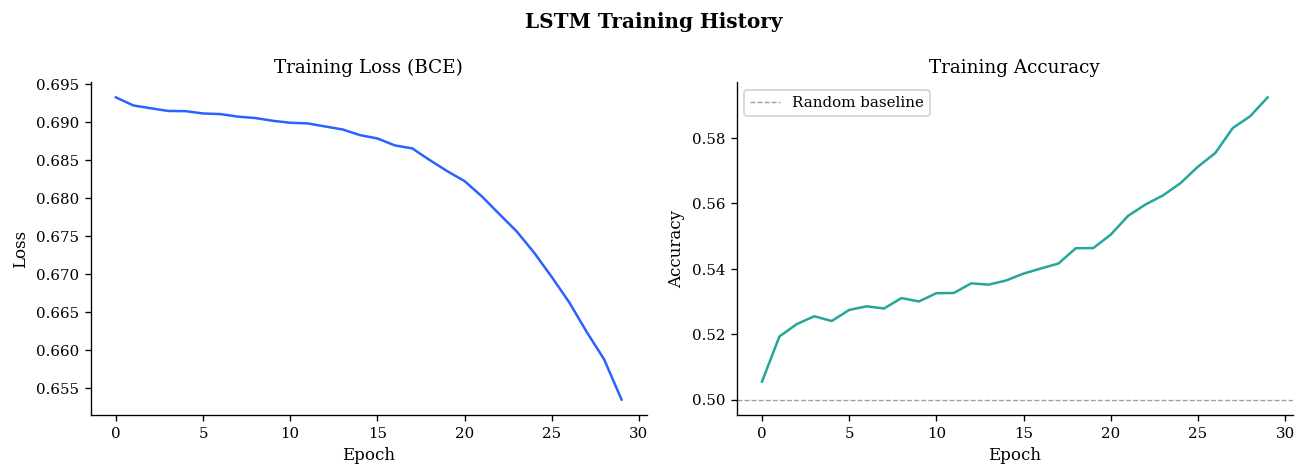

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history['train_loss'], color=BLUE, lw=1.5)
ax1.set_title('Training Loss (BCE)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax2.plot(history['train_acc'], color=GREEN, lw=1.5)
ax2.axhline(0.5, color=GREY, ls='--', lw=0.8, label='Random baseline')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend()
fig.suptitle('LSTM Training History', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lstm_training_history.png')
plt.show()


## 6. Test-set signal generation

Run the frozen model over the test window.
For each timestep, record the predicted probability (confidence) that the next candle is up.

In [9]:
model.eval()
with torch.no_grad():
    X_t = torch.from_numpy(X_test).to(DEVICE)
    probs = model(X_t).cpu().numpy()   # shape: (N,)

# Align with test_df index (offset by SEQ_LEN)
signal_index = test_df.index[SEQ_LEN:]
close_prices = test_df['close'].values[SEQ_LEN:]
true_labels  = y_test

test_accuracy = ((probs > 0.5) == true_labels).mean()
print(f'Test accuracy (direction): {test_accuracy:.4f}')
print(f'Signals above entry threshold ({CONFIDENCE_THRESHOLD}): '
      f'{(probs >= CONFIDENCE_THRESHOLD).sum():,} / {len(probs):,}')


Test accuracy (direction): 0.5148
Signals above entry threshold (0.62): 697 / 12,792


## 7. Backtest

**Entry:** confidence ≥ `CONFIDENCE_THRESHOLD` and currently flat.

**Exit:** any of:
- confidence drops below `EXIT_THRESHOLD`
- price hits take-profit (+3%)
- price hits stop-loss (−2%)

Binary position: all-in / all-out. Fee applied on each trade.

In [10]:
equity   = 1.0
cash     = 1.0
units    = 0.0
in_pos   = False
entry_px = 0.0

equity_curve = [equity]
trade_log    = []   # (entry_time, exit_time, entry_px, exit_px, pnl, reason)

for i, (ts, px, conf) in enumerate(zip(signal_index, close_prices, probs)):
    if in_pos:
        pnl_pct = (px - entry_px) / entry_px
        reason  = None

        if pnl_pct >= TAKE_PROFIT:
            reason = 'tp'
        elif pnl_pct <= -STOP_LOSS:
            reason = 'sl'
        elif conf < EXIT_THRESHOLD:
            reason = 'conf'

        if reason:
            proceeds = units * px * (1 - FEE)
            trade_log.append({
                'entry_time': entry_ts, 'exit_time': ts,
                'entry_px': entry_px,   'exit_px': px,
                'pnl_pct':  pnl_pct,    'reason': reason,
            })
            cash    = proceeds
            units   = 0.0
            in_pos  = False

    if not in_pos and conf >= CONFIDENCE_THRESHOLD:
        spend    = cash * (1 - FEE)
        units    = spend / px
        cash     = 0.0
        in_pos   = True
        entry_px = px
        entry_ts = ts

    current_equity = cash + units * px
    equity_curve.append(current_equity)

# Force-close any open position at last price
if in_pos:
    px = close_prices[-1]
    proceeds = units * px * (1 - FEE)
    trade_log.append({
        'entry_time': entry_ts, 'exit_time': signal_index[-1],
        'entry_px': entry_px,   'exit_px': px,
        'pnl_pct':  (px - entry_px) / entry_px, 'reason': 'eod',
    })
    cash = proceeds
    equity_curve[-1] = cash

equity_arr = np.array(equity_curve[1:])   # align length with signal_index
trades_df  = pd.DataFrame(trade_log)
print(f'Total trades: {len(trades_df)}')
if not trades_df.empty:
    print(trades_df['reason'].value_counts().to_string())


Total trades: 547
reason
conf    531
sl       15
tp        1


## 8. Buy-and-hold benchmark

In [11]:
bh_entry = close_prices[0]
bh_units = (1.0 * (1 - FEE)) / bh_entry
bh_equity = bh_units * close_prices * 1.0   # mark-to-market
bh_final  = bh_units * close_prices[-1] * (1 - FEE)


## 9. Metrics

In [12]:
def sharpe(returns, ann_factor=24*365):
    r = np.array(returns)
    if len(r) < 2 or r.std() == 0:
        return 0.0
    return float((r.mean() / (r.std(ddof=1) + 1e-12)) * np.sqrt(ann_factor))

def max_dd(equity):
    eq = np.array(equity)
    peak = np.maximum.accumulate(eq)
    return float(((eq - peak) / (peak + 1e-12)).min())

def log_returns(equity):
    eq = np.array(equity)
    return np.log(eq[1:] / (eq[:-1] + 1e-12))

lstm_ret   = log_returns(equity_arr)
bh_ret     = log_returns(bh_equity)

metrics = pd.DataFrame([
    {
        'Strategy':       'LSTM Agent',
        'Total Return':   f'{(equity_arr[-1] - 1) * 100:.2f}%',
        'Sharpe (ann.)':  f'{sharpe(lstm_ret):.3f}',
        'Max Drawdown':   f'{max_dd(equity_arr) * 100:.2f}%',
        'Num Trades':     len(trades_df),
        'Win Rate':       f'{(trades_df["pnl_pct"] > 0).mean() * 100:.1f}%' if not trades_df.empty else 'N/A',
        'Avg Trade PnL':  f'{trades_df["pnl_pct"].mean() * 100:.2f}%' if not trades_df.empty else 'N/A',
    },
    {
        'Strategy':       'Buy & Hold',
        'Total Return':   f'{(bh_final - 1) * 100:.2f}%',
        'Sharpe (ann.)':  f'{sharpe(bh_ret):.3f}',
        'Max Drawdown':   f'{max_dd(bh_equity) * 100:.2f}%',
        'Num Trades':     1,
        'Win Rate':       'N/A',
        'Avg Trade PnL':  'N/A',
    },
]).set_index('Strategy')

print(metrics.to_string())


           Total Return Sharpe (ann.) Max Drawdown  Num Trades Win Rate Avg Trade PnL
Strategy                                                                             
LSTM Agent      -45.48%        -2.770      -47.07%         547    50.5%        -0.01%
Buy & Hold      -13.08%        -0.207      -50.08%           1      N/A           N/A


## 10. Results visualisation

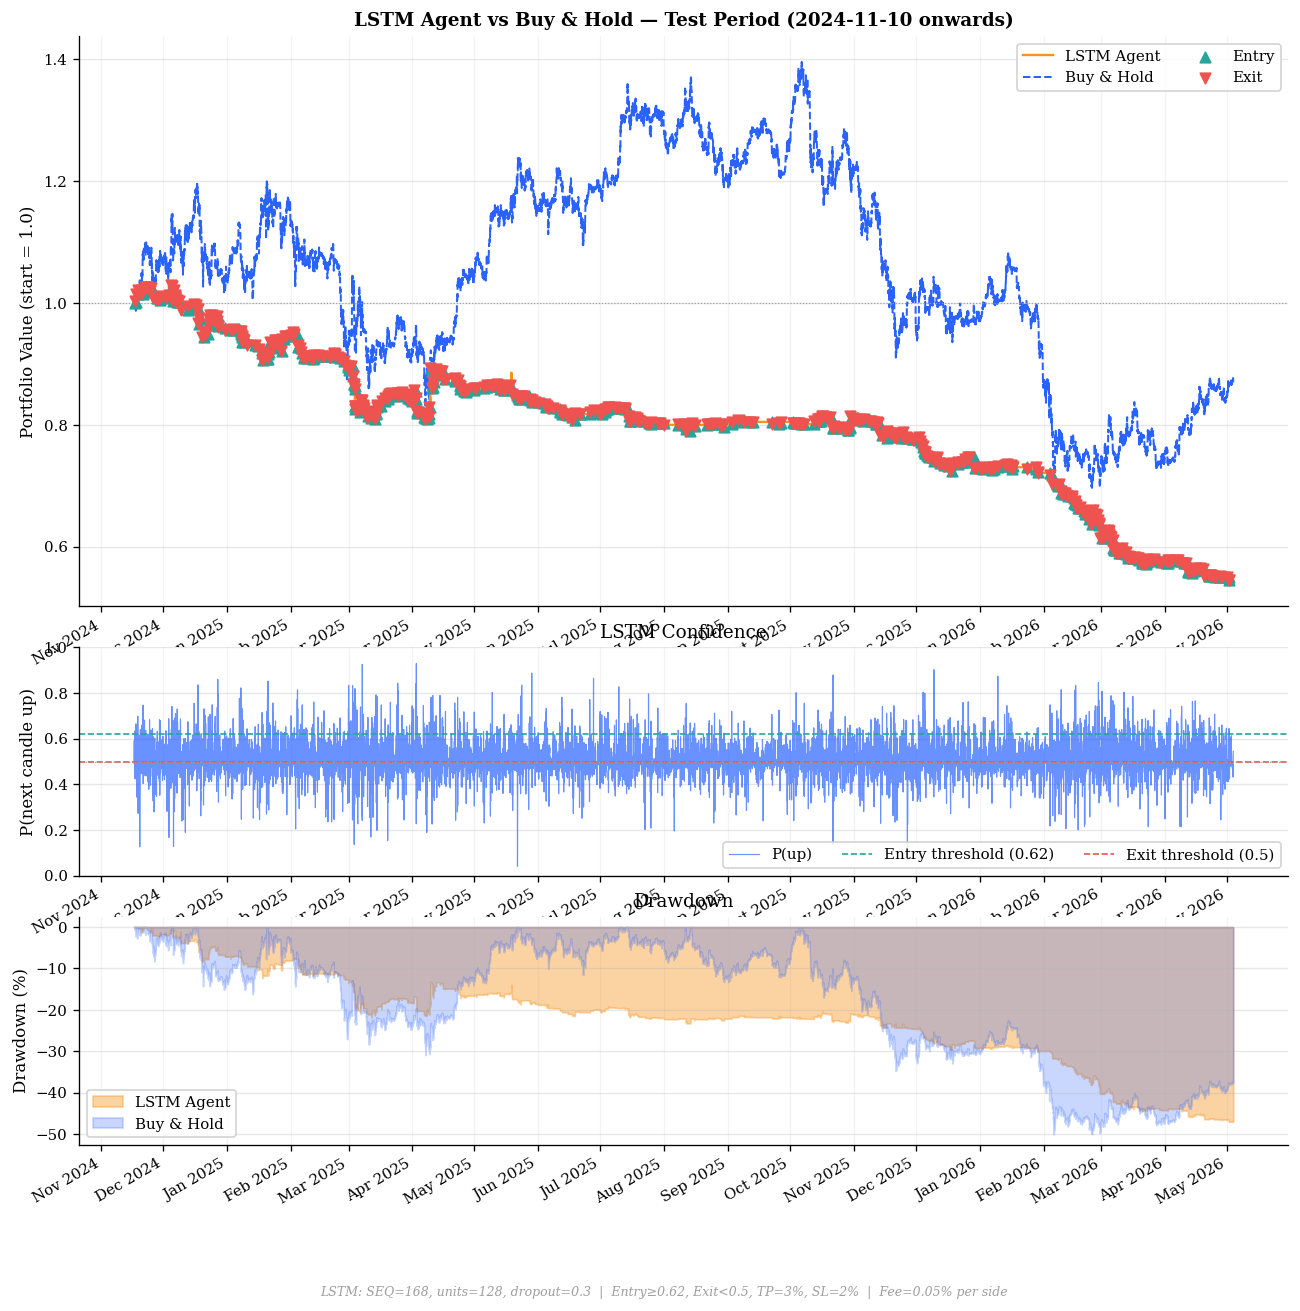

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.12})

# ── Equity curves ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(signal_index, equity_arr, color=ACCENT, lw=1.4, label='LSTM Agent', zorder=3)
ax.plot(signal_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold', zorder=2)
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')

# Mark trades
if not trades_df.empty:
    entries = trades_df['entry_time']
    exits   = trades_df['exit_time']
    entry_vals = pd.Series(equity_arr, index=signal_index).reindex(entries, method='nearest')
    exit_vals  = pd.Series(equity_arr, index=signal_index).reindex(exits,   method='nearest')
    ax.scatter(entries, entry_vals, marker='^', color=GREEN, s=40, zorder=5, label='Entry')
    ax.scatter(exits,   exit_vals,  marker='v', color=RED,   s=40, zorder=5, label='Exit')

ax.set_ylabel('Portfolio Value (start = 1.0)')
ax.set_title('LSTM Agent vs Buy & Hold — Test Period (2024-11-10 onwards)',
             fontweight='bold')
ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Confidence signal ─────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(signal_index, probs, color=BLUE, lw=0.7, alpha=0.7, label='P(up)')
ax.axhline(CONFIDENCE_THRESHOLD, color=GREEN, ls='--', lw=1.0,
           label=f'Entry threshold ({CONFIDENCE_THRESHOLD})')
ax.axhline(EXIT_THRESHOLD, color=RED, ls='--', lw=1.0,
           label=f'Exit threshold ({EXIT_THRESHOLD})')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0, 1)
ax.set_ylabel('P(next candle up)')
ax.set_title('LSTM Confidence')
ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[2]
peak_lstm = np.maximum.accumulate(equity_arr)
peak_bh   = np.maximum.accumulate(bh_equity)
dd_lstm   = (equity_arr - peak_lstm) / (peak_lstm + 1e-12) * 100
dd_bh     = (bh_equity  - peak_bh)  / (peak_bh   + 1e-12) * 100
ax.fill_between(signal_index, dd_lstm, 0, color=ACCENT, alpha=0.4, label='LSTM Agent')
ax.fill_between(signal_index, dd_bh,   0, color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown')
ax.legend()
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'LSTM: SEQ={SEQ_LEN}, units={LSTM_UNITS}, dropout={DROPOUT}  |  '
    f'Entry≥{CONFIDENCE_THRESHOLD}, Exit<{EXIT_THRESHOLD}, TP={TAKE_PROFIT*100:.0f}%, SL={STOP_LOSS*100:.0f}%  |  '
    f'Fee={FEE*100:.2f}% per side',
    ha='center', fontsize=7.5, color='#9E9E9E', style='italic')

fig.savefig(FIGURES_DIR / 'lstm_backtest_results.png')
plt.show()


## 11. Trade log

In [14]:
if not trades_df.empty:
    trades_df['duration_h'] = (trades_df['exit_time'] - trades_df['entry_time']).dt.total_seconds() / 3600
    trades_df['pnl_pct_fmt'] = trades_df['pnl_pct'].apply(lambda x: f'{x*100:+.2f}%')
    display_cols = ['entry_time', 'exit_time', 'duration_h', 'entry_px', 'exit_px', 'pnl_pct_fmt', 'reason']
    print(f'Avg holding time: {trades_df["duration_h"].mean():.1f}h')
    print(f'Median holding time: {trades_df["duration_h"].median():.1f}h')
    trades_df[display_cols]


Avg holding time: 2.1h
Median holding time: 2.0h
